##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [ ]:
!pip -q install opencv-python tensorflow scikit-learn matplotlib

In [ ]:
import os
import cv2
import random
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# Create working directories
BASE_DIR = "/content/action_recognition_lab"
DATA_DIR = os.path.join(BASE_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)

dataset_zip = os.path.join(DATA_DIR, "UCF11_updated_mpg.rar")
dataset_folder = os.path.join(DATA_DIR, "UCF11_updated_mpg")

print("Directories ready.")

Directories ready.


In [ ]:
!wget --no-check-certificate -O "/content/action_recognition_lab/data/UCF11_updated_mpg.rar" \
"https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar"

--2026-04-22 18:28:53--  https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 1045106394 (997M) [application/x-rar-compressed]
Saving to: ‘/content/action_recognition_lab/data/UCF11_updated_mpg.rar’

/content/action_rec 100%[===================>] 996.69M   109MB/s    in 13s     

2026-04-22 18:29:07 (74.2 MB/s) - ‘/content/action_recognition_lab/data/UCF11_updated_mpg.rar’ saved [1045106394/1045106394]



In [ ]:
!apt-get -qq install unrar
!unrar x -o+ "/content/action_recognition_lab/data/UCF11_updated_mpg.rar" "/content/action_recognition_lab/data/"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/action_recognition_lab/data/UCF11_updated_mpg.rar

Creating    /content/action_recognition_lab/data/UCF11_updated_mpg    OK
Creating    /content/action_recognition_lab/data/UCF11_updated_mpg/basketball  OK
Creating    /content/action_recognition_lab/data/UCF11_updated_mpg/basketball/v_shooting_01  OK
Extracting  /content/action_recognition_lab/data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_01.mpg       0%  OK 
Extracting  /content/action_recognition_lab/data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_02.mpg       0%  OK 
Extracting  /content/action_recognition_lab/data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_03.mpg       0%  OK 
Extracting  /content/action_recognition_lab/data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_04.mpg       0%  OK 
Extracting  /content/action_recognition_lab/data/UCF1

In [ ]:
!ls /content/action_recognition_lab/data/UCF11_updated_mpg

basketball  golf_swing	     swing		 volleyball_spiking
biking	    horse_riding     tennis_swing	 walking
diving	    soccer_juggling  trampoline_jumping


In [ ]:
root = Path(dataset_folder)

all_items = sorted([p.name for p in root.iterdir() if p.is_dir()])
print("Available classes/folders:")
for item in all_items:
    print(item)

Available classes/folders:
basketball
biking
diving
golf_swing
horse_riding
soccer_juggling
swing
tennis_swing
trampoline_jumping
volleyball_spiking
walking


##Select 3 classes

In [ ]:
SELECTED_CLASSES = [
    "basketball",
    "biking",
    "walking"
]

print("Chosen classes:", SELECTED_CLASSES)

Chosen classes: ['basketball', 'biking', 'walking']


In [ ]:
from pathlib import Path

def collect_video_paths(dataset_root, selected_classes, max_videos_per_class=None):
    video_paths = []
    labels = []

    for class_name in selected_classes:
        class_dir = Path(dataset_root) / class_name

        if not class_dir.exists():
            print(f"Warning: {class_name} folder not found")
            continue

        class_videos = []
        for ext in ["*.mpg", "*.avi", "*.mp4", "*.mov"]:
            class_videos.extend(list(class_dir.rglob(ext)))

        class_videos = sorted(class_videos)

        if max_videos_per_class is not None:
            class_videos = class_videos[:max_videos_per_class]

        video_paths.extend(class_videos)
        labels.extend([class_name] * len(class_videos))

        print(f"{class_name}: {len(class_videos)} videos")

    return video_paths, labels

video_paths, labels = collect_video_paths(
    dataset_folder,
    SELECTED_CLASSES,
    max_videos_per_class=80
)

print("Total videos:", len(video_paths))

basketball: 80 videos
biking: 80 videos
walking: 80 videos
Total videos: 240


In [ ]:
IMG_SIZE = 128
SEQUENCE_LENGTH = 16

#Preprocess the dataset

In [ ]:
import cv2
import numpy as np

def extract_frames_from_video(video_path, sequence_length=16, img_size=128):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    frame_indices = np.linspace(0, total_frames - 1, sequence_length, dtype=int)

    current_idx = 0
    selected_set = set(frame_indices.tolist())

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_idx in selected_set:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frame = frame.astype("float32") / 255.0
            frames.append(frame)

        current_idx += 1

    cap.release()

    if len(frames) == 0:
        return None

    while len(frames) < sequence_length:
        frames.append(frames[-1])

    frames = frames[:sequence_length]
    return np.array(frames, dtype=np.float32)

In [ ]:
X = []
y = []

for i, (video_path, label) in enumerate(zip(video_paths, labels)):
    frames = extract_frames_from_video(str(video_path), SEQUENCE_LENGTH, IMG_SIZE)

    if frames is not None:
        X.append(frames)
        y.append(label)

    if (i + 1) % 20 == 0:
        print(f"Processed {i+1}/{len(video_paths)} videos")

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Processed 20/240 videos
Processed 40/240 videos
Processed 60/240 videos
Processed 80/240 videos
Processed 100/240 videos
Processed 120/240 videos
Processed 140/240 videos
Processed 160/240 videos
Processed 180/240 videos
Processed 200/240 videos
Processed 220/240 videos
Processed 240/240 videos
X shape: (240, 16, 128, 128, 3)
y shape: (240,)


#Split the data into training and testing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("Classes:", label_encoder.classes_)

Train: (192, 16, 128, 128, 3) (192, 3)
Test : (48, 16, 128, 128, 3) (48, 3)
Classes: ['basketball' 'biking' 'walking']


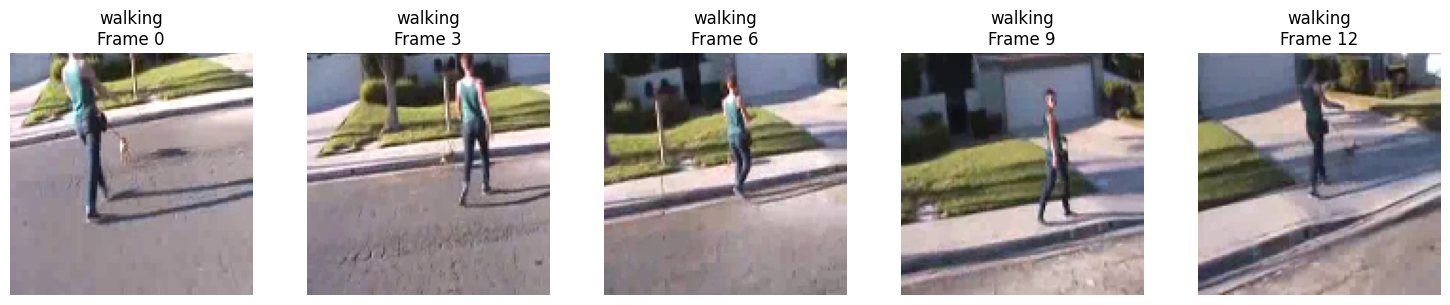

In [ ]:
import matplotlib.pyplot as plt

def show_sample_sequence(sample_frames, label_name, num_frames=5):
    plt.figure(figsize=(15, 3))
    step = max(1, len(sample_frames) // num_frames)

    for i, idx in enumerate(range(0, len(sample_frames), step)):
        if i >= num_frames:
            break
        plt.subplot(1, num_frames, i + 1)
        plt.imshow(sample_frames[idx])
        plt.axis("off")
        plt.title(f"{label_name}\nFrame {idx}")
    plt.tight_layout()
    plt.show()

sample_idx = 0
sample_label = label_encoder.inverse_transform([np.argmax(y_train[sample_idx])])[0]
show_sample_sequence(X_train[sample_idx], sample_label)

In [ ]:
X_train_small = X_train[:, ::2]
X_test_small  = X_test[:, ::2]

print("X_train_small:", X_train_small.shape)
print("X_test_small :", X_test_small.shape)

X_train_small: (192, 8, 128, 128, 3)
X_test_small : (48, 8, 128, 128, 3)


#Create and train the model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

light_model = models.Sequential([
    layers.Input(shape=(8, 128, 128, 3)),

    layers.TimeDistributed(layers.Conv2D(8, (3, 3), activation='relu', padding='same')),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

    layers.TimeDistributed(layers.Conv2D(16, (3, 3), activation='relu', padding='same')),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

    layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same')),
    layers.TimeDistributed(layers.GlobalAveragePooling2D()),

    layers.GRU(32),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(3, activation='softmax')
])

light_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

light_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_7              │ (None, 8, 128, 128, 8) │           224 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 8, 64, 64, 8)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 8, 64, 64, 16)  │         1,168 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 8, 32, 32, 16)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 8, 32, 32, 32)  │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 8, 32)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,523 (52.82 KB)

 Trainable params: 13,523 (52.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]

history = light_model.fit(
    X_train_small, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.3007 - loss: 1.1067 - val_accuracy: 0.2564 - val_loss: 1.1317
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.3660 - loss: 1.0943 - val_accuracy: 0.2564 - val_loss: 1.1402
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.3333 - loss: 1.1016 - val_accuracy: 0.2564 - val_loss: 1.1374
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.3529 - loss: 1.1029 - val_accuracy: 0.2564 - val_loss: 1.1171
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.3464 - loss: 1.1033 - val_accuracy: 0.2564 - val_loss: 1.1293
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.3333 - loss: 1.0943 - val_accuracy: 0.2564 - val_loss: 1.1407
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.3660 - loss: 1.0948 - val_accuracy: 0.2564 - val_loss: 1.1452


In [ ]:
light_model = models.Sequential([
    layers.Input(shape=(8, 128, 128, 3)),

    layers.TimeDistributed(layers.Conv2D(16, (3, 3), activation='relu', padding='same')),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

    layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same')),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

    layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu', padding='same')),
    layers.TimeDistributed(layers.GlobalAveragePooling2D()),

    layers.GRU(64),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')
])

In [ ]:
light_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )
]

history = light_model.fit(
    X_train_small, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.3464 - loss: 1.1082 - val_accuracy: 0.2564 - val_loss: 1.1158
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.3660 - loss: 1.0944 - val_accuracy: 0.2564 - val_loss: 1.1311
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.3464 - loss: 1.0951 - val_accuracy: 0.2564 - val_loss: 1.1229
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.3464 - loss: 1.0809 - val_accuracy: 0.2564 - val_loss: 1.1179
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.3791 - loss: 1.0627 - val_accuracy: 0.3333 - val_loss: 1.1103
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.4118 - loss: 1.0427 - val_accuracy: 0.3077 - val_loss: 1.1115
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.4248 - loss: 1.0328 - val_accuracy: 0.3590 - val_loss: 1.1157
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.4575 - loss: 1.0170 - val_accuracy: 0.2821 - val_loss:

In [ ]:
test_loss, test_acc = light_model.evaluate(X_test_small, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 1.0923
Test Accuracy: 0.4583


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred_probs = light_model.predict(X_test_small)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step
              precision    recall  f1-score   support

  basketball       0.62      0.50      0.55        16
      biking       0.40      0.88      0.55        16
     walking       0.00      0.00      0.00        16

    accuracy                           0.46        48
   macro avg       0.34      0.46      0.37        48
weighted avg       0.34      0.46      0.37        48



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


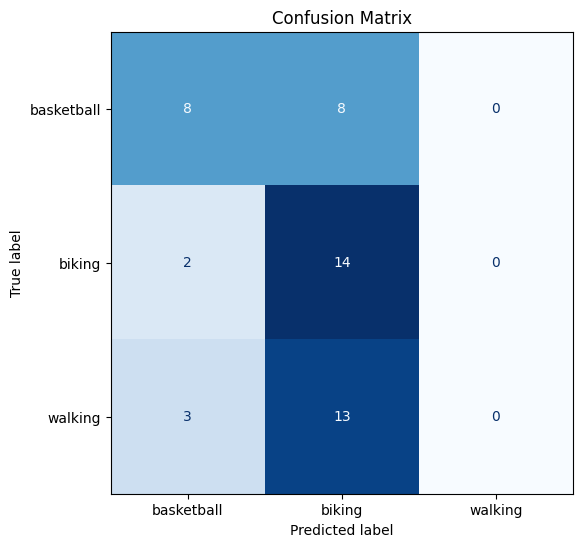

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

#Save the trained model

In [ ]:
student_name = "ReemZaki"
save_path = f"/content/{student_name}_ucf11_model.h5"

light_model.save(save_path)
print("Model saved to:", save_path)

Model saved to: /content/ReemZaki_ucf11_model.h5


#Validate the model on 3 Youtube videos

In [ ]:
import pickle

label_path = f"/content/{student_name}_label_encoder.pkl"
with open(label_path, "wb") as f:
    pickle.dump(label_encoder, f)

print("Label encoder saved to:", label_path)

Label encoder saved to: /content/ReemZaki_label_encoder.pkl


In [ ]:
!pip install -q yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 50.6 MB/s eta 0:00:00


In [ ]:
!yt-dlp -f mp4 -o "basketball.mp4" "https://youtube.com/shorts/BWV1f3Y-J9U?si=oiePZU99qy0YpfNB"

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://youtube.com/shorts/BWV1f3Y-J9U?si=oiePZU99qy0YpfNB
[youtube] BWV1f3Y-J9U: Downloading webpage
[youtube] BWV1f3Y-J9U: Downloading android vr player API JSON
[info] BWV1f3Y-J9U: Downloading 1 format(s): 18
[download] Destination: basketball.mp4
[download] 100% of  832.05KiB in 00:00:00 at 3.82MiB/s


In [ ]:
!yt-dlp -f mp4 -o "biking.mp4" "https://youtu.be/-jDKJT2dDZQ?si=lnMlcI_rbi6YDcq7"

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://youtu.be/-jDKJT2dDZQ?si=lnMlcI_rbi6YDcq7
[youtube] -jDKJT2dDZQ: Downloading webpage
[youtube] -jDKJT2dDZQ: Downloading android vr player API JSON
[info] -jDKJT2dDZQ: Downloading 1 format(s): 18
[download] Destination: biking.mp4
[download] 100% of   19.20MiB in 00:00:01 at 15.36MiB/s


In [ ]:
!yt-dlp -f mp4 -o "walking.mp4" "https://youtu.be/84lYjtCfIvY?si=O_sKsCjWVKv8Nj6-"

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://youtu.be/84lYjtCfIvY?si=O_sKsCjWVKv8Nj6-
[youtube] 84lYjtCfIvY: Downloading webpage
[youtube] 84lYjtCfIvY: Downloading android vr player API JSON
[info] 84lYjtCfIvY: Downloading 1 format(s): 18
[download] Destination: walking.mp4
[download] 100% of  422.44KiB in 00:00:00 at 1.74MiB/s


In [ ]:
!ls

action_recognition_lab	ReemZaki_label_encoder.pkl  walking.mp4
basketball.mp4		ReemZaki_ucf11_model.h5
biking.mp4		sample_data


In [ ]:
import cv2
import numpy as np

def extract_frames_for_prediction(video_path, sequence_length=8, img_size=128):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return None

    frame_indices = np.linspace(0, total_frames - 1, sequence_length, dtype=int)
    current_idx = 0
    selected_set = set(frame_indices.tolist())

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_idx in selected_set:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frame = frame.astype("float32") / 255.0
            frames.append(frame)

        current_idx += 1

    cap.release()

    if len(frames) == 0:
        return None

    while len(frames) < sequence_length:
        frames.append(frames[-1])

    frames = frames[:sequence_length]
    return np.array(frames, dtype=np.float32)

In [ ]:
def predict_video(video_path, model, label_encoder, sequence_length=8, img_size=128):
    frames = extract_frames_for_prediction(video_path, sequence_length, img_size)
    if frames is None:
        return None, None

    x = np.expand_dims(frames, axis=0)
    probs = model.predict(x, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    confidence = probs[pred_idx]

    return pred_label, confidence

In [ ]:
video_files = ["basketball.mp4", "biking.mp4", "walking.mp4"]

for file_name in video_files:
    pred_label, confidence = predict_video(
        file_name,
        light_model,
        label_encoder,
        sequence_length=8,
        img_size=128
    )

    print(f"Video: {file_name}")
    print(f"Predicted action: {pred_label}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 50)

Video: basketball.mp4
Predicted action: basketball
Confidence: 0.4077
--------------------------------------------------
Video: biking.mp4
Predicted action: biking
Confidence: 0.3512
--------------------------------------------------
Video: walking.mp4
Predicted action: biking
Confidence: 0.3524
--------------------------------------------------


The trained model was evaluated on three external videos downloaded from YouTube, representing basketball, biking, and walking actions. The model successfully classified the basketball and biking videos correctly. However, the walking video was misclassified as biking. This behavior is consistent with the earlier evaluation results, where the model showed difficulty distinguishing the walking class. This is likely due to the subtle motion patterns in walking compared to the more distinctive movements in biking and basketball. Overall, the model demonstrates reasonable generalization capability despite its limitations.